<a href="https://colab.research.google.com/github/junseok-jay/AI_lab/blob/main/week9/vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

# cuDNN을 사용하여 Convolution 연산 최적화 설정
cudnn.benchmark = True
plt.ion()   # interactive mode

In [56]:
import zipfile
import os

# ZIP 압축 해제하는 함수
def extract_zip_file(zip_file_path, extraction_path):
    """ZIP 파일을 지정된 경로에 압축 해제합니다."""
    os.makedirs(extraction_path, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_path)
        print(f"Successfully extracted {zip_file_path} to {extraction_path}")
    except FileNotFoundError:
        print(f"Error: The file '{zip_file_path}' was not found.")
        raise
    except zipfile.BadZipFile:
        print(f"Error: The file '{zip_file_path}' is not a valid zip file or is corrupted.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")
        raise

# 데이터셋을 로드하는 함수
def load_image_datasets(data_dir, data_transforms):
    """디렉토리에서 이미지 데이터셋을 로드합니다."""
    try:
        image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                                  data_transforms[x])
                          for x in ['train', 'val']}
        dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                                     shuffle=True, num_workers=4)
                      for x in ['train', 'val']}
        dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
        class_names = image_datasets['train'].classes
        return image_datasets, dataloaders, dataset_sizes, class_names
    except Exception as e:
        print(f"An error occurred during dataset loading: {e}")
        raise

# 파일 경로 정의
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/AI_lab/week9/sample_computer_vision.zip'
extraction_path = './data/sample_computer_vision'
data_dir = os.path.join(extraction_path, 'sample_computer_vision')

# 학습을 위한 데이터 증강 및 정규화
# 검증을 위한 정규화
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 데이터셋 압축 해제, 로딩
extract_zip_file(zip_file_path, extraction_path)
image_datasets, dataloaders, dataset_sizes, class_names = load_image_datasets(data_dir, data_transforms)

# 사용할 장치 (GPU 또는 CPU) 결정, cuda 사용
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Successfully extracted /content/drive/MyDrive/Colab Notebooks/AI_lab/week9/sample_computer_vision.zip to ./data/sample_computer_vision
Using cuda device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


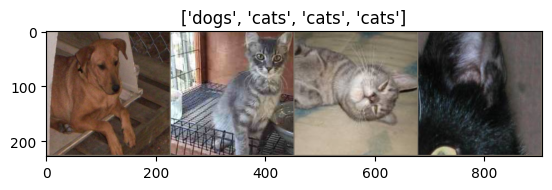

In [57]:
# 텐서 이미지를 표시하는 함수
def imshow(inp, title=None):
    """텐서 이미지를 표시합니다."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # 플롯 업테이트를 위한 대기


# 학습 데이터 배치 가져오기
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [58]:
# 모델 학습 함수
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [59]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()


    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)


            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])


                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [60]:
# ImageNet1K 데이터셋으로 사전 학습된 ResNet18 모델 로드
model_load = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_load.fc.in_features
model_load.fc = nn.Linear(num_ftrs, 2)

model_load = model_load.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_load.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [61]:
# 모델 학습 시작 (25 에포크)
my_model = train_model(model_load, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5770 Acc: 0.7565
val Loss: 0.6964 Acc: 0.7200

Epoch 1/24
----------
train Loss: 0.5046 Acc: 0.7864
val Loss: 0.2783 Acc: 0.9050

Epoch 2/24
----------
train Loss: 0.5836 Acc: 0.7824
val Loss: 0.1621 Acc: 0.9350

Epoch 3/24
----------
train Loss: 0.5949 Acc: 0.7774
val Loss: 0.2124 Acc: 0.9550

Epoch 4/24
----------
train Loss: 0.4527 Acc: 0.8333
val Loss: 0.2112 Acc: 0.9300

Epoch 5/24
----------
train Loss: 0.5024 Acc: 0.8104
val Loss: 0.2115 Acc: 0.9400

Epoch 6/24
----------
train Loss: 0.3950 Acc: 0.8104
val Loss: 0.1188 Acc: 0.9650

Epoch 7/24
----------
train Loss: 0.2963 Acc: 0.8723
val Loss: 0.1037 Acc: 0.9700

Epoch 8/24
----------
train Loss: 0.2743 Acc: 0.8772
val Loss: 0.1025 Acc: 0.9750

Epoch 9/24
----------
train Loss: 0.2332 Acc: 0.8992
val Loss: 0.1153 Acc: 0.9650

Epoch 10/24
----------
train Loss: 0.2670 Acc: 0.8802
val Loss: 0.1143 Acc: 0.9700

Epoch 11/24
----------
train Loss: 0.2796 Acc: 0.8882
val Loss: 0.1044 Acc: 0.9750

Ep

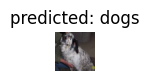

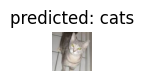

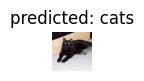

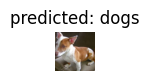

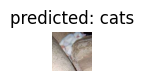

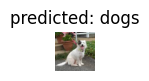

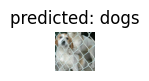

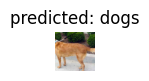

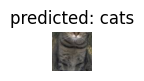

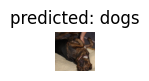

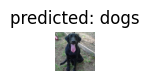

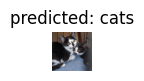

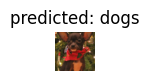

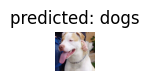

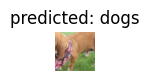

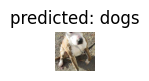

In [62]:
# 학습된 모델의 예측 결과를 시각화 (16개의 이미지)
visualize_model(my_model, num_images=16)

In [63]:
# ImageNet1K 데이터셋으로 사전 학습된 ResNet18 모델 로드
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')

for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)
criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [64]:
# 정의된 함수와 파라미터를 사용하여 컨볼루션 모델 학습 시작 (25 에포크)
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.4757 Acc: 0.7814
val Loss: 0.1153 Acc: 0.9650

Epoch 1/24
----------
train Loss: 0.4618 Acc: 0.8204
val Loss: 0.1111 Acc: 0.9700

Epoch 2/24
----------
train Loss: 0.5308 Acc: 0.8004
val Loss: 0.1036 Acc: 0.9750

Epoch 3/24
----------
train Loss: 0.5116 Acc: 0.8074
val Loss: 0.1112 Acc: 0.9700

Epoch 4/24
----------
train Loss: 0.4238 Acc: 0.8244
val Loss: 0.2235 Acc: 0.9200

Epoch 5/24
----------
train Loss: 0.6294 Acc: 0.7994
val Loss: 0.4316 Acc: 0.8800

Epoch 6/24
----------
train Loss: 0.5101 Acc: 0.8154
val Loss: 0.1719 Acc: 0.9350

Epoch 7/24
----------
train Loss: 0.3908 Acc: 0.8383
val Loss: 0.1149 Acc: 0.9700

Epoch 8/24
----------
train Loss: 0.3754 Acc: 0.8433
val Loss: 0.1030 Acc: 0.9750

Epoch 9/24
----------
train Loss: 0.3230 Acc: 0.8633
val Loss: 0.1236 Acc: 0.9650

Epoch 10/24
----------
train Loss: 0.3467 Acc: 0.8533
val Loss: 0.1160 Acc: 0.9700

Epoch 11/24
----------
train Loss: 0.3544 Acc: 0.8473
val Loss: 0.0923 Acc: 0.9800

Ep

In [65]:
# 단일 이미지에 대한 모델 예측을 시각화하는 함수
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    # 이미지 로드 및 전처리
    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

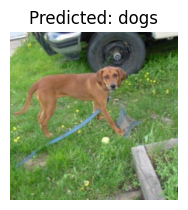

In [66]:
# 컨볼루션 모델을 사용하여 특정 이미지에 대한 예측 시각화
img_path='/content/data/sample_computer_vision/sample_computer_vision/val/dogs/dog.4021.jpg'

visualize_model_predictions(model_conv, img_path)

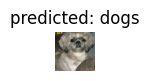

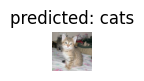

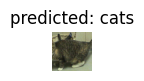

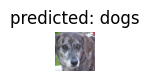

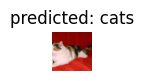

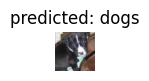

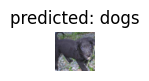

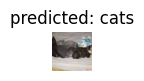

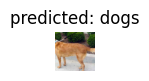

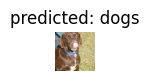

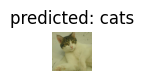

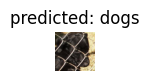

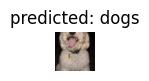

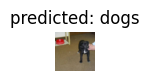

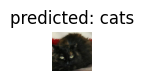

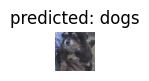

In [67]:
# 컨볼루션 모델을 사용하여 여러 이미지에 대한 예측 시각화
visualize_model(model_conv, num_images=16)